In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import pandas as pd
import ast

df = pd.read_csv(
    "/content/drive/MyDrive/AI POWERED PERSONALISED LEARNING PATH GENERATOR/Dataset/Processed/career_dataset_cleaned.csv"
)

# Convert the skill column back to a Python list
df["job_skill_set"] = df["job_skill_set"].apply(ast.literal_eval)

df.head()

,category,job_title,job_description,job_skill_set
0,HR,Sr Human Resource Generalist,THE SR. HR GENERALIST PROVIDES HR EXPERTISE AC...,"[Employee Relations, Talent Acquisition, Perfo..."
1,HR,Human Resources Manager,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGE...,"[Talent Acquisition, Employee Performance Mana..."
2,HR,Director of Human Resources,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING...,"[Human Resources Management, Recruitment, Empl..."
3,HR,Chief Human Resources Officer,CHIEF HUMAN RESOURCES OFFICER (CHRO)INDUSTRY: ...,"[Talent Management, Organizational Development..."
4,HR,Human Resources Generalist (Hybrid Role),WHO WE ARE AVI-SPL IS A DIGITAL ENABLEMENT SOL...,"[Microsoft Office, Data Analysis, Employee Onb..."


In [11]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

df.head()

Shape: (1167, 4)

Columns:
Index(['category', 'job_title', 'job_description', 'job_skill_set'], dtype='object')

Missing Values:
category           0
job_title          0
job_description    0
job_skill_set      0
dtype: int64


,category,job_title,job_description,job_skill_set
0,HR,Sr Human Resource Generalist,THE SR. HR GENERALIST PROVIDES HR EXPERTISE AC...,"[Employee Relations, Talent Acquisition, Perfo..."
1,HR,Human Resources Manager,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGE...,"[Talent Acquisition, Employee Performance Mana..."
2,HR,Director of Human Resources,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING...,"[Human Resources Management, Recruitment, Empl..."
3,HR,Chief Human Resources Officer,CHIEF HUMAN RESOURCES OFFICER (CHRO)INDUSTRY: ...,"[Talent Management, Organizational Development..."
4,HR,Human Resources Generalist (Hybrid Role),WHO WE ARE AVI-SPL IS A DIGITAL ENABLEMENT SOL...,"[Microsoft Office, Data Analysis, Employee Onb..."


In [12]:
category_counts = df['category'].value_counts()

print(category_counts)

category
Information Technology    240
Business Development      239
Finance                   236
Sales                     232
HR                        220
Name: count, dtype: int64


In [13]:
print("Number of Categories:", df['category'].nunique())
print("Categories:")
print(df['category'].unique())

Number of Categories: 5
Categories:
['HR' 'Information Technology' 'Sales' 'Finance' 'Business Development']


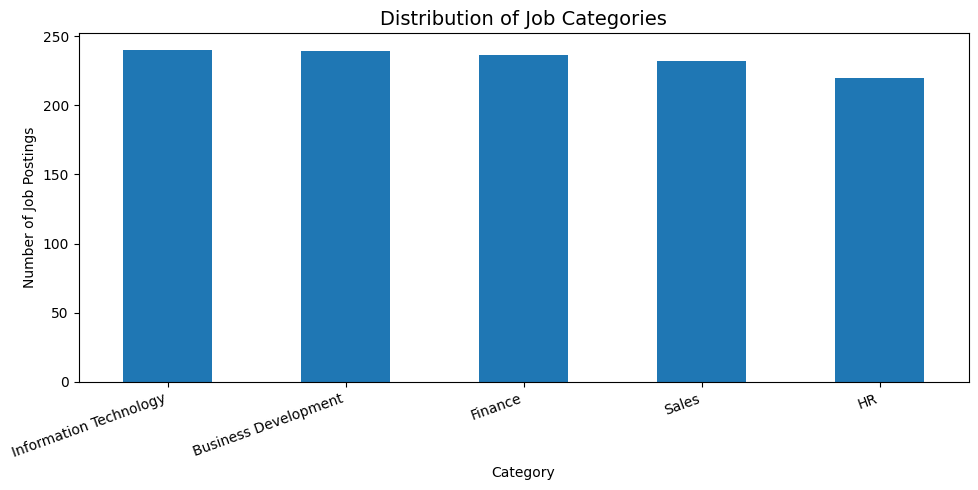

In [15]:
plt.figure(figsize=(10,5))

category_counts.plot(kind='bar')

plt.title("Distribution of Job Categories", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.show()

In [16]:
print("Total Job Postings :", len(df))
print("Unique Job Titles :", df['job_title'].nunique())
print("Duplicate Job Titles :", df['job_title'].duplicated().sum())

Total Job Postings : 1167
Unique Job Titles : 720
Duplicate Job Titles : 447


In [17]:
top_jobs = df['job_title'].value_counts().head(10)

print(top_jobs)

job_title
Business Development Manager                 53
Human Resources Generalist                   34
Business Development Representative          33
Human Resources Manager                      29
Information Technology Support Specialist    16
Finance Manager                              15
Human Resources Business Partner             15
Director of Finance                          13
Information Technology Project Manager       11
Human Resources Coordinator                  11
Name: count, dtype: int64


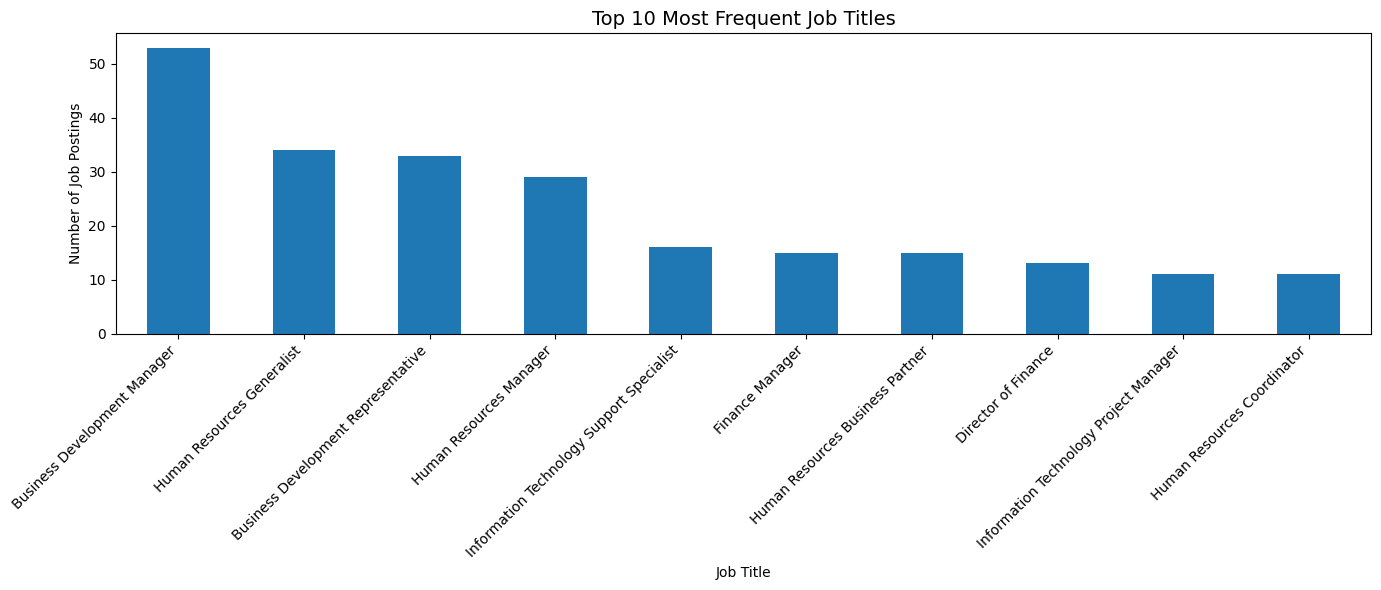

In [19]:
plt.figure(figsize=(14,6))

top_jobs.plot(kind='bar')

plt.title("Top 10 Most Frequent Job Titles", fontsize=14)
plt.xlabel("Job Title")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [20]:
from collections import Counter

all_skills = []

for skills in df['job_skill_set']:
    all_skills.extend(skills)

print("Total Skills:", len(all_skills))
print("Unique Skills:", len(set(all_skills)))

Total Skills: 20833
Unique Skills: 4984


In [21]:
skill_counts = Counter(all_skills)

top_skills = skill_counts.most_common(20)

for skill, count in top_skills:
    print(f"{skill}: {count}")

Communication: 1092
Problem Solving: 878
Adaptability: 588
Teamwork: 569
Collaboration: 341
Leadership: 325
Time Management: 316
Interpersonal Skills: 288
Customer Service: 272
Relationship Building: 267
Attention To Detail: 253
Data Analysis: 251
Project Management: 234
Organizational Skills: 231
Negotiation: 157
Sales: 148
Presentation Skills: 144
Business Development: 137
Financial Analysis: 131
Strategic Thinking: 127


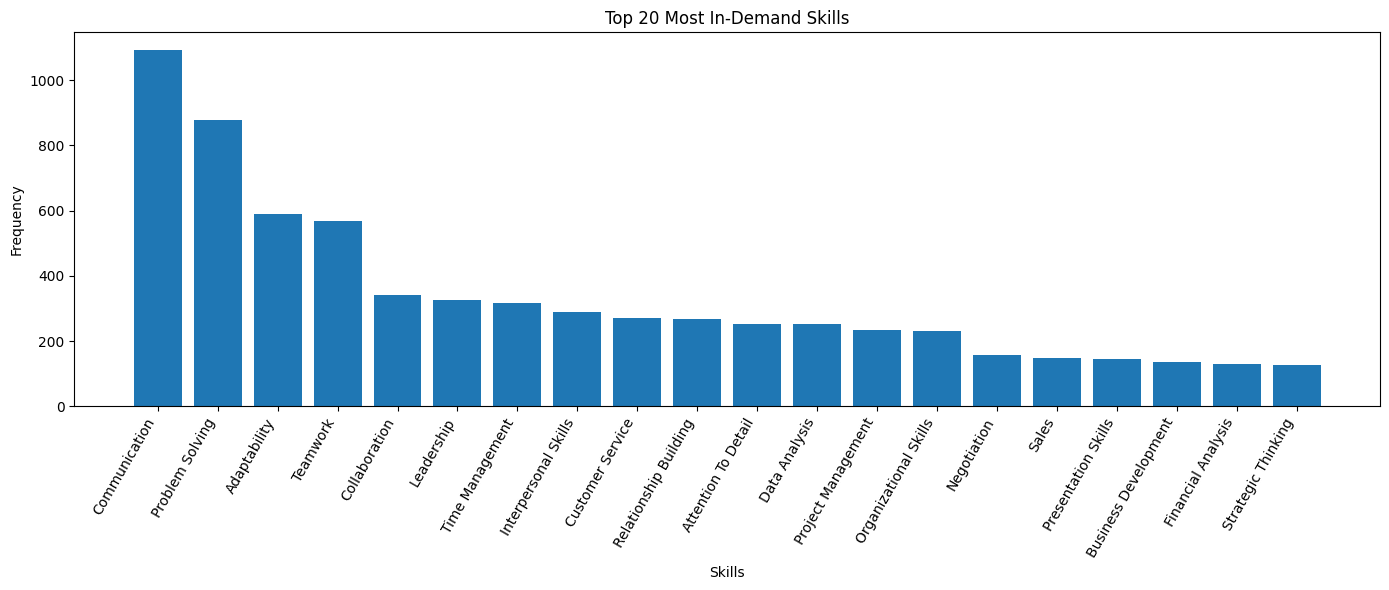

In [22]:
import matplotlib.pyplot as plt

skills = [x[0] for x in top_skills]
counts = [x[1] for x in top_skills]

plt.figure(figsize=(14,6))

plt.bar(skills, counts)

plt.title("Top 20 Most In-Demand Skills")
plt.xlabel("Skills")
plt.ylabel("Frequency")

plt.xticks(rotation=60, ha='right')

plt.tight_layout()
plt.show()

In [23]:
df['num_skills'] = df['job_skill_set'].apply(len)

print("Average Skills per Job :", round(df['num_skills'].mean(),2))
print("Minimum Skills :", df['num_skills'].min())
print("Maximum Skills :", df['num_skills'].max())

Average Skills per Job : 17.85
Minimum Skills : 5
Maximum Skills : 43


In [24]:
# Number of characters in each description
df['description_length'] = df['job_description'].apply(len)

print("Average Description Length:", round(df['description_length'].mean(), 2))
print("Minimum Description Length:", df['description_length'].min())
print("Maximum Description Length:", df['description_length'].max())

Average Description Length: 3755.97
Minimum Description Length: 167
Maximum Description Length: 13613


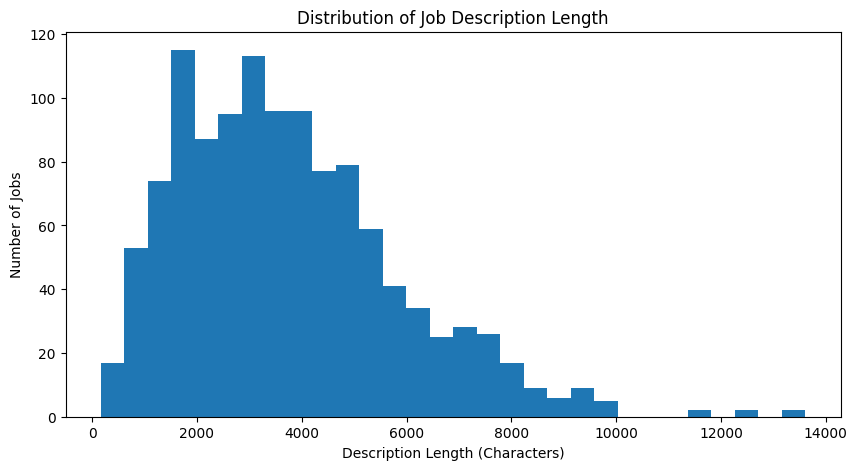

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df['description_length'], bins=30)

plt.title("Distribution of Job Description Length")
plt.xlabel("Description Length (Characters)")
plt.ylabel("Number of Jobs")

plt.show()

In [26]:
avg_skills_category = (
    df.groupby("category")["num_skills"]
      .mean()
      .sort_values(ascending=False)
)

print(avg_skills_category)

category
HR                        19.145455
Information Technology    19.054167
Finance                   18.618644
Business Development      16.740586
Sales                     15.745690
Name: num_skills, dtype: float64


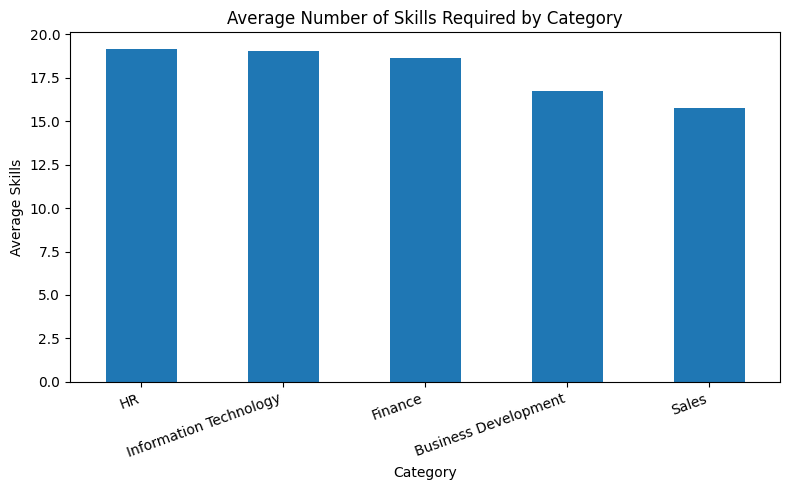

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

avg_skills_category.plot(kind="bar")

plt.title("Average Number of Skills Required by Category")
plt.xlabel("Category")
plt.ylabel("Average Skills")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [28]:
avg_desc_category = (
    df.groupby("category")["description_length"]
      .mean()
      .sort_values(ascending=False)
)

print(avg_desc_category)

category
Finance                   4233.711864
HR                        4039.640909
Business Development      3722.355649
Sales                     3550.375000
Information Technology    3258.387500
Name: description_length, dtype: float64


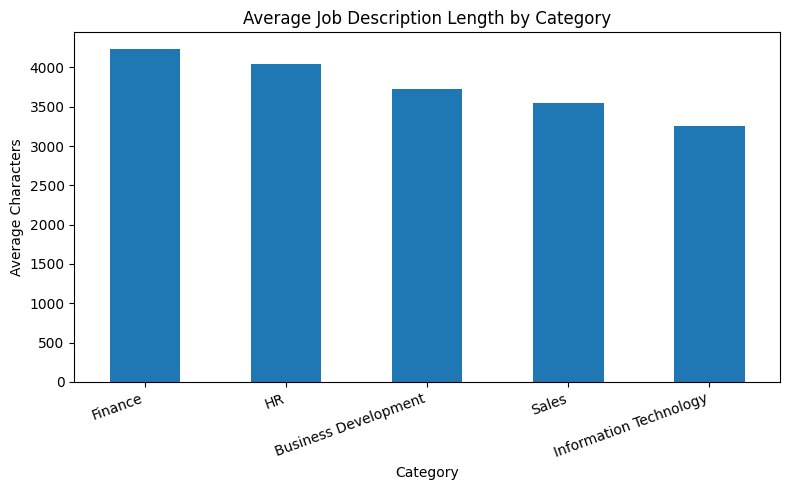

In [29]:
plt.figure(figsize=(8,5))

avg_desc_category.plot(kind="bar")

plt.title("Average Job Description Length by Category")
plt.xlabel("Category")
plt.ylabel("Average Characters")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [30]:
from collections import Counter

for category in df["category"].unique():

    print("=" * 60)
    print(f"Category: {category}")

    category_df = df[df["category"] == category]

    skills = []

    for skill_list in category_df["job_skill_set"]:
        skills.extend(skill_list)

    top10 = Counter(skills).most_common(10)

    for skill, count in top10:
        print(f"{skill}: {count}")

    print()

Category: HR
Communication: 207
Problem Solving: 171
Employee Relations: 102
Adaptability: 102
Teamwork: 101
Interpersonal Skills: 99
Attention To Detail: 81
Performance Management: 79
Data Analysis: 76
Leadership: 72

Category: Information Technology
Communication: 219
Problem Solving: 191
Adaptability: 112
Teamwork: 101
Collaboration: 88
Project Management: 84
Leadership: 69
Customer Service: 66
Time Management: 57
Attention To Detail: 51

Category: Sales
Communication: 220
Problem Solving: 162
Teamwork: 147
Adaptability: 135
Customer Service: 120
Sales: 77
Time Management: 73
Relationship Building: 68
Customer Relationship Management: 44
Product Knowledge: 44

Category: Finance
Communication: 221
Problem Solving: 185
Teamwork: 117
Financial Analysis: 108
Adaptability: 105
Leadership: 104
Collaboration: 96
Financial Reporting: 91
Data Analysis: 70
Attention To Detail: 69

Category: Business Development
Communication: 225
Problem Solving: 169
Adaptability: 134
Business Development: 11